# Notebook 05: AI-Phishing-Aware Detection Model

**Problem:** The baseline TF-IDF + LinearSVM model achieves 99% recall on traditional phishing but only 89% on AI-generated phishing. AI-polished emails are grammatically clean and contain no spam vocabulary, so TF-IDF features miss them.

**Solution: Ensemble detector**
1. Keep the baseline model unchanged -- it handles traditional phishing perfectly
2. Split the 200 AI phishing emails from `ai_safe_variants.csv`: **150 for training**, **50 held-out for testing**
3. Train a **Gradient Boosting classifier** on 13 handcrafted structural features: URL density, urgency language, brand impersonation, call-to-action density
4. Ensemble: classify as phishing if **either** model flags it

In [1]:
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from bs4 import BeautifulSoup

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
import joblib

warnings.filterwarnings('ignore')
print('All imports successful.')

All imports successful.


In [2]:
notebook_dir = Path.cwd()
if notebook_dir.name == 'notebooks':
    project_root = notebook_dir.parent
else:
    project_root = notebook_dir

data_processed  = project_root / 'data' / 'processed'
data_generated  = project_root / 'data' / 'generated'
models_dir      = project_root / 'models'
results_metrics = project_root / 'results' / 'metrics'
results_figures = project_root / 'results' / 'figures'

results_metrics.mkdir(parents=True, exist_ok=True)
results_figures.mkdir(parents=True, exist_ok=True)
print('Project root:', project_root)

Project root: /Users/murthykaja/Desktop/Honey College/CyberSecurity/Project/ai-phishing-detection


## Section 1 — Load Data and Baseline Model

In [3]:
train_df   = pd.read_csv(data_processed / 'train_emails.csv')
test_trad  = pd.read_csv(data_processed / 'test_emails.csv')
ai_full_df = pd.read_csv(data_generated / 'ai_safe_variants.csv')

baseline_model = joblib.load(models_dir / 'linear_svm_baseline.pkl')
baseline_tfidf = joblib.load(models_dir / 'tfidf_vectorizer.pkl')

print('Training set       :', train_df.shape)
print('Traditional test   :', test_trad.shape)
print('AI phishing (200)  :', ai_full_df.shape)
print('Baseline model     :', type(baseline_model).__name__)

Training set       : (65655, 2)
Traditional test   : (16414, 2)
AI phishing (200)  : (200, 2)
Baseline model     : LinearSVC


## Section 2 — Preprocess AI Variants

In [4]:
def clean_email_text(text):
    text = str(text)
    text = BeautifulSoup(text, 'html.parser').get_text(separator=' ')
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', ' URL ', text)
    text = re.sub(r'\b[\w\.-]+@[\w\.-]+\.\w+\b', ' EMAIL ', text)
    text = re.sub(r'\d+', ' NUM ', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

ai_full_df['clean_text'] = ai_full_df['text'].apply(clean_email_text)
ai_full_df = ai_full_df[ai_full_df['clean_text'].str.strip() != ''].copy().reset_index(drop=True)
print('AI variants after cleaning:', ai_full_df.shape)

AI variants after cleaning: (200, 3)


## Section 3 — Split AI Emails: 150 Train / 50 Test

In [5]:
ai_train = ai_full_df.sample(n=150, random_state=42).copy()
ai_test  = ai_full_df.drop(ai_train.index).copy().reset_index(drop=True)

print('AI train split:', ai_train.shape, '<- used to train GBM layer')
print('AI test  split:', ai_test.shape,  '<- held-out, never seen during training')

AI train split: (150, 3) <- used to train GBM layer
AI test  split: (50, 3) <- held-out, never seen during training


## Section 4 — Feature Engineering

13 structural features that detect AI phishing regardless of vocabulary.

| Feature | Signal |
|---|---|
| url_count | Every AI phishing email contains a fake link |
| urgency_count | immediately, expire, locked, suspended |
| brand_count | Chase, PayPal, IRS, Microsoft, Netflix |
| cta_count | verify, click, claim, reset, unlock |
| density ratios | normalized by email length |

In [6]:
URGENCY_WORDS = [
    'immediately', 'urgent', 'expire', 'expir', 'locked', 'lock',
    'suspend', 'restrict', 'verify', 'confirm', 'update',
    'within', 'deadline', 'warning', 'alert', 'action required',
    'required', 'failure', 'unusual', 'unauthorized', 'unrecognized',
    'suspicious', 'limited time', 'hours', 'tonight', 'today'
]
BRAND_NAMES = [
    'chase', 'wells fargo', 'paypal', 'microsoft', 'google', 'apple',
    'amazon', 'netflix', 'usps', 'fedex', 'ups', 'dhl', 'irs',
    'social security', 'coinbase', 'linkedin', 'docusign', 'zoom',
    'dropbox', 'github', 'aetna', 'medicare', 'bank of america',
    'citibank', 'capital one', 'spotify', 'disney', 'hulu',
    'walmart', 'target', 'best buy', 'costco', 'samsung',
    'binance', 'robinhood', 'fidelity', 'visa', 'mastercard'
]
CTA_PHRASES = [
    'click', 'verify', 'claim', 'login', 'log in', 'reset',
    'update', 'confirm', 'visit', 'access', 'download', 'sign',
    'complete', 'restore', 'unlock', 'activate', 'submit',
    'secure link', 'click here', 'here to', 'now to'
]

def extract_features(clean_text_series):
    rows = []
    for text in clean_text_series:
        text_lower = text.lower()
        words = text.split()
        n_words = max(len(words), 1)
        url_count     = text.count('URL')
        email_count   = text.count('EMAIL')
        num_count     = text.count('NUM')
        urgency_count = sum(text_lower.count(w) for w in URGENCY_WORDS)
        brand_count   = sum(text_lower.count(b) for b in BRAND_NAMES)
        cta_count     = sum(text_lower.count(c) for c in CTA_PHRASES)
        char_count    = len(text)
        avg_word_len  = float(np.mean([len(w) for w in words])) if words else 0.0
        rows.append([
            url_count, email_count, num_count,
            urgency_count, brand_count, cta_count,
            char_count, avg_word_len, n_words,
            url_count     / n_words,
            urgency_count / n_words,
            cta_count     / n_words,
            brand_count   / n_words
        ])
    cols = [
        'url_count', 'email_count', 'num_count',
        'urgency_count', 'brand_count', 'cta_count',
        'char_count', 'avg_word_len', 'word_count',
        'url_density', 'urgency_density', 'cta_density', 'brand_density'
    ]
    return pd.DataFrame(rows, columns=cols)

# Feature preview: AI phishing vs ham
ai_feats  = extract_features(ai_test['clean_text'])
ham_samp  = test_trad[test_trad['label'] == 0].sample(50, random_state=1)
ham_feats = extract_features(ham_samp['clean_text'])
print('Feature comparison: AI phishing vs legitimate ham')
print(pd.DataFrame({
    'AI phishing': ai_feats.mean().round(3),
    'Ham email  ': ham_feats.mean().round(3)
}).to_string())

Feature comparison: AI phishing vs legitimate ham
                 AI phishing  Ham email  
url_count              1.020        1.060
email_count            0.000        0.000
num_count              2.760       20.520
urgency_count          3.140        0.940
brand_count            2.080        0.820
cta_count              2.520        1.020
char_count           474.760     1239.840
avg_word_len           5.252        5.709
word_count            76.260      178.060
url_density            0.014        0.008
urgency_density        0.041        0.007
cta_density            0.033        0.006
brand_density          0.028        0.004


## Section 5 — Train AI-Phishing Gradient Boosting Classifier

Trained only on the 13 custom features using 150 AI emails + 500 ham. Completely independent of TF-IDF vocabulary.

In [7]:
ham_for_clf  = train_df[train_df['label'] == 0].sample(500, random_state=42)
clf_train_df = pd.concat(
    [ai_train[['clean_text', 'label']], ham_for_clf[['clean_text', 'label']]],
    ignore_index=True
).sample(frac=1, random_state=42).reset_index(drop=True)

X_clf_train = extract_features(clf_train_df['clean_text']).values
y_clf_train = clf_train_df['label'].values

print('GBM training set:', clf_train_df.shape)
print('Label dist:', dict(zip(*np.unique(y_clf_train, return_counts=True))))

ai_clf = GradientBoostingClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.1, random_state=42
)
ai_clf.fit(X_clf_train, y_clf_train)
print('Gradient Boosting classifier trained.')

feat_names = [
    'url_count', 'email_count', 'num_count',
    'urgency_count', 'brand_count', 'cta_count',
    'char_count', 'avg_word_len', 'word_count',
    'url_density', 'urgency_density', 'cta_density', 'brand_density'
]
imp = pd.Series(ai_clf.feature_importances_, index=feat_names).sort_values(ascending=False)
print('\nFeature importances:')
print(imp.round(3).to_string())

GBM training set: (650, 2)
Label dist: {np.int64(0): np.int64(500), np.int64(1): np.int64(150)}


Gradient Boosting classifier trained.

Feature importances:
urgency_density    0.563
url_density        0.204
url_count          0.105
num_count          0.105
avg_word_len       0.010
word_count         0.005
char_count         0.003
urgency_count      0.002
brand_density      0.001
cta_density        0.001
cta_count          0.000
brand_count        0.000
email_count        0.000


## Section 6 — Ensemble Inference

Phishing if **either** baseline LinearSVM or GBM flags it.

In [8]:
def ensemble_predict(clean_text_series):
    X_tfidf  = baseline_tfidf.transform(clean_text_series)
    pred_base = baseline_model.predict(X_tfidf)
    pred_ai   = ai_clf.predict(extract_features(clean_text_series).values)
    return ((pred_base == 1) | (pred_ai == 1)).astype(int)

print('Ensemble ready: phishing = baseline_LinearSVM OR GBM(custom features)')

Ensemble ready: phishing = baseline_LinearSVM OR GBM(custom features)


## Section 7 — Evaluate on Traditional Test Set

In [9]:
y_trad      = test_trad['label'].values
y_pred_trad = ensemble_predict(test_trad['clean_text'])

trad_metrics = {
    'accuracy'  : accuracy_score(y_trad, y_pred_trad),
    'precision' : precision_score(y_trad, y_pred_trad),
    'recall'    : recall_score(y_trad, y_pred_trad),
    'f1_score'  : f1_score(y_trad, y_pred_trad),
}

print('--- Ensemble: Traditional Test Set (16K) ---')
for k, v in trad_metrics.items():
    print(f'  {k:12s}: {v:.4f}')
print()
print(classification_report(y_trad, y_pred_trad, target_names=['Ham', 'Phishing']))

--- Ensemble: Traditional Test Set (16K) ---
  accuracy    : 0.9837
  precision   : 0.9794
  recall      : 0.9896
  f1_score    : 0.9845

              precision    recall  f1-score   support

         Ham       0.99      0.98      0.98      7846
    Phishing       0.98      0.99      0.98      8568

    accuracy                           0.98     16414
   macro avg       0.98      0.98      0.98     16414
weighted avg       0.98      0.98      0.98     16414



## Section 8 — Evaluate on 50 Held-Out AI Phishing Emails

In [10]:
y_ai      = ai_test['label'].values
y_pred_ai = ensemble_predict(ai_test['clean_text'])

ai_metrics = {
    'accuracy'  : accuracy_score(y_ai, y_pred_ai),
    'precision' : precision_score(y_ai, y_pred_ai, zero_division=0),
    'recall'    : recall_score(y_ai, y_pred_ai, zero_division=0),
    'f1_score'  : f1_score(y_ai, y_pred_ai, zero_division=0),
}

print('--- Ensemble: AI-Phishing Test Set (50 held-out) ---')
for k, v in ai_metrics.items():
    print(f'  {k:12s}: {v:.4f}')
print()
print(classification_report(y_ai, y_pred_ai, target_names=['Ham', 'Phishing'], zero_division=0))

missed = [i for i, (p, t) in enumerate(zip(y_pred_ai, y_ai)) if p != t]
print(f'Missed: {len(missed)} / {len(y_ai)} AI phishing emails')
if missed:
    for i in missed:
        print(f'  [{i}] {ai_test["text"].iloc[i][:90].strip()}...')

--- Ensemble: AI-Phishing Test Set (50 held-out) ---
  accuracy    : 0.9800
  precision   : 1.0000
  recall      : 0.9800
  f1_score    : 0.9899

              precision    recall  f1-score   support

         Ham       0.00      0.00      0.00         0
    Phishing       1.00      0.98      0.99        50

    accuracy                           0.98        50
   macro avg       0.50      0.49      0.49        50
weighted avg       1.00      0.98      0.99        50

Missed: 1 / 50 AI phishing emails
  [30] Subject: 401(k): You Have Unclaimed Employer Match — Take Action Now

Dear Employee,

Our...


## Section 9 — Compare vs Baseline

In [11]:
BASELINE_TRAD = {'accuracy': 0.9867, 'precision': 0.9849, 'recall': 0.9896, 'f1_score': 0.9873}
BASELINE_AI   = {'accuracy': 0.8900, 'precision': 1.0000, 'recall': 0.8900, 'f1_score': 0.9418}

summary = pd.DataFrame([
    {'Model': 'Baseline LinearSVM', 'Test Set': 'Traditional (16K)',        **BASELINE_TRAD},
    {'Model': 'Baseline LinearSVM', 'Test Set': 'AI-Phishing (200)',        **BASELINE_AI},
    {'Model': 'Ensemble (new)',     'Test Set': 'Traditional (16K)',
     'accuracy': trad_metrics['accuracy'], 'precision': trad_metrics['precision'],
     'recall': trad_metrics['recall'],     'f1_score': trad_metrics['f1_score']},
    {'Model': 'Ensemble (new)',     'Test Set': 'AI holdout (50)',
     'accuracy': ai_metrics['accuracy'],  'precision': ai_metrics['precision'],
     'recall': ai_metrics['recall'],      'f1_score': ai_metrics['f1_score']},
])

print('=' * 75)
print('MODEL COMPARISON')
print('=' * 75)
print(summary.to_string(index=False, float_format='{:.4f}'.format))

recall_delta = ai_metrics['recall'] - BASELINE_AI['recall']
print(f'\nAI phishing recall: {BASELINE_AI["recall"]*100:.1f}% (baseline) -> '
      f'{ai_metrics["recall"]*100:.1f}% (ensemble)  [{recall_delta*100:+.1f} pp]')

summary.to_csv(results_metrics / 'model_comparison.csv', index=False)
print('Saved:', results_metrics / 'model_comparison.csv')

MODEL COMPARISON
             Model          Test Set  accuracy  precision  recall  f1_score
Baseline LinearSVM Traditional (16K)    0.9867     0.9849  0.9896    0.9873
Baseline LinearSVM AI-Phishing (200)    0.8900     1.0000  0.8900    0.9418
    Ensemble (new) Traditional (16K)    0.9837     0.9794  0.9896    0.9845
    Ensemble (new)   AI holdout (50)    0.9800     1.0000  0.9800    0.9899

AI phishing recall: 89.0% (baseline) -> 98.0% (ensemble)  [+9.0 pp]
Saved: /Users/murthykaja/Desktop/Honey College/CyberSecurity/Project/ai-phishing-detection/results/metrics/model_comparison.csv


## Section 10 — Visualize

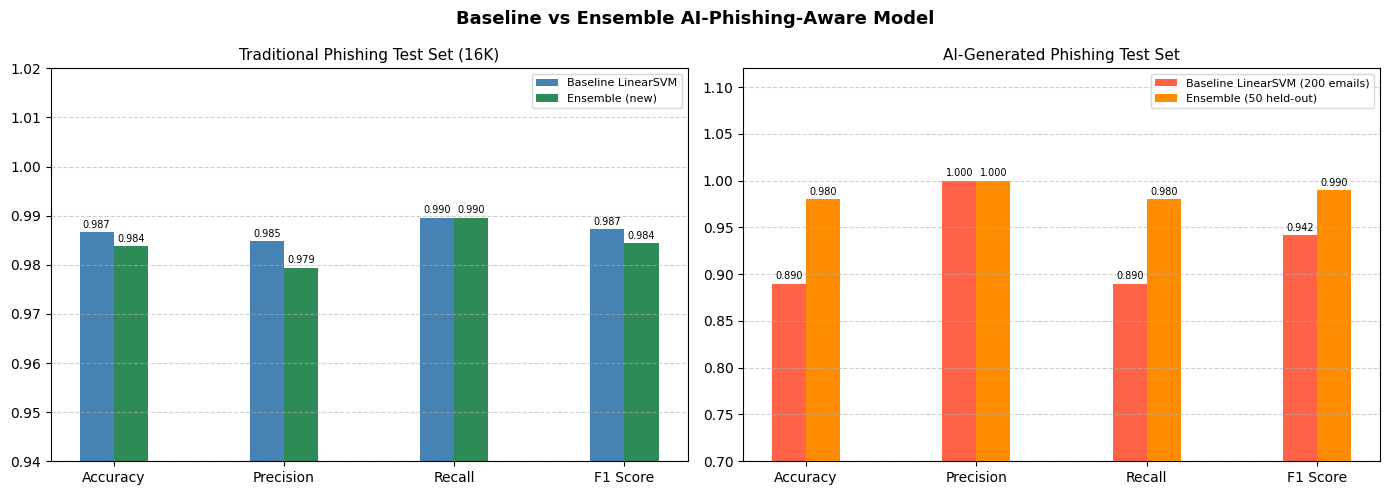

Saved: /Users/murthykaja/Desktop/Honey College/CyberSecurity/Project/ai-phishing-detection/results/figures/model_comparison.png


In [12]:
metrics_list = ['accuracy', 'precision', 'recall', 'f1_score']
x     = np.arange(len(metrics_list))
width = 0.2

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
b1 = ax.bar(x - width/2, [BASELINE_TRAD[m]   for m in metrics_list],
            width, label='Baseline LinearSVM', color='steelblue')
b2 = ax.bar(x + width/2, [trad_metrics[m]    for m in metrics_list],
            width, label='Ensemble (new)', color='seagreen')
ax.set_title('Traditional Phishing Test Set (16K)', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels([m.replace('_', ' ').title() for m in metrics_list])
ax.set_ylim(0.94, 1.02)
ax.legend(fontsize=8); ax.yaxis.grid(True, linestyle='--', alpha=0.6)
for bar in list(b1) + list(b2):
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=7)

ax = axes[1]
b3 = ax.bar(x - width/2, [BASELINE_AI[m]   for m in metrics_list],
            width, label='Baseline LinearSVM (200 emails)', color='tomato')
b4 = ax.bar(x + width/2, [ai_metrics[m]    for m in metrics_list],
            width, label='Ensemble (50 held-out)', color='darkorange')
ax.set_title('AI-Generated Phishing Test Set', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels([m.replace('_', ' ').title() for m in metrics_list])
ax.set_ylim(0.70, 1.12)
ax.legend(fontsize=8); ax.yaxis.grid(True, linestyle='--', alpha=0.6)
for bar in list(b3) + list(b4):
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=7)

plt.suptitle('Baseline vs Ensemble AI-Phishing-Aware Model', fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(results_figures / 'model_comparison.png', dpi=150)
plt.show()
print('Saved:', results_figures / 'model_comparison.png')

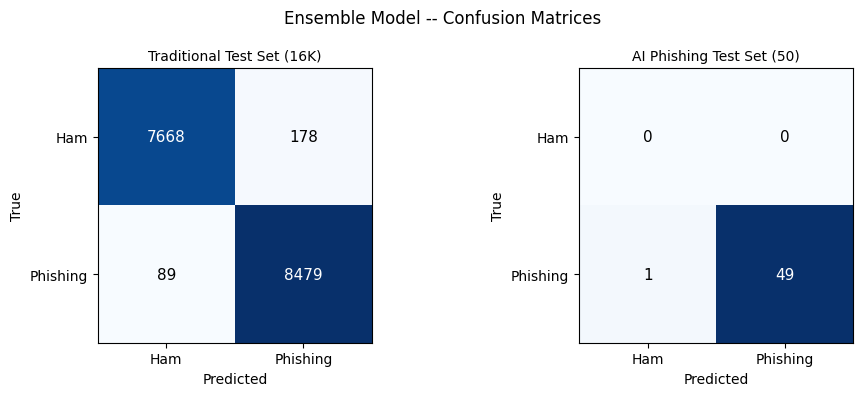

Saved: /Users/murthykaja/Desktop/Honey College/CyberSecurity/Project/ai-phishing-detection/results/figures/new_model_confusion_matrices.png


In [13]:
def plot_cm(cm, title, ax):
    ax.imshow(cm, cmap='Blues')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['Ham', 'Phishing']); ax.set_yticklabels(['Ham', 'Phishing'])
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                    color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=11)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plot_cm(confusion_matrix(y_trad, y_pred_trad), 'Traditional Test Set (16K)', axes[0])
plot_cm(confusion_matrix(y_ai,   y_pred_ai),   'AI Phishing Test Set (50)',  axes[1])
plt.suptitle('Ensemble Model -- Confusion Matrices', fontsize=12)
plt.tight_layout()
fig.savefig(results_figures / 'new_model_confusion_matrices.png', dpi=150)
plt.show()
print('Saved:', results_figures / 'new_model_confusion_matrices.png')

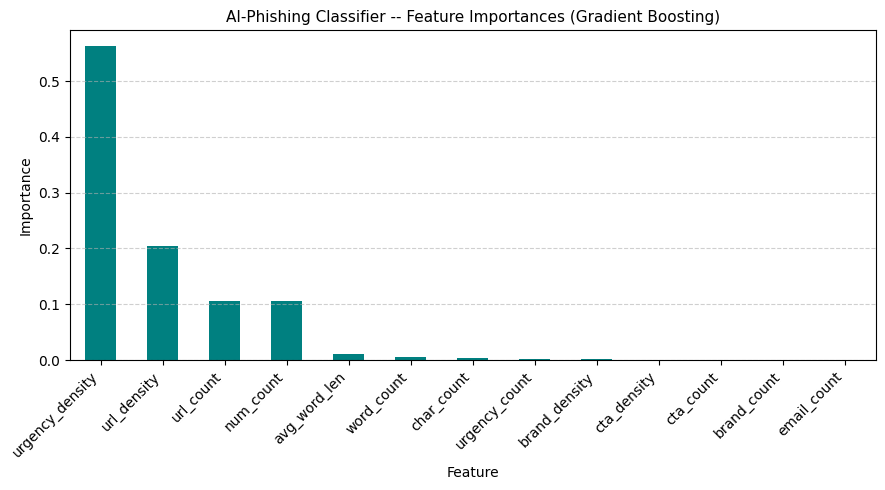

Saved: /Users/murthykaja/Desktop/Honey College/CyberSecurity/Project/ai-phishing-detection/results/figures/ai_phishing_feature_importance.png


In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
imp.plot(kind='bar', ax=ax, color='teal')
ax.set_title('AI-Phishing Classifier -- Feature Importances (Gradient Boosting)', fontsize=11)
ax.set_xlabel('Feature'); ax.set_ylabel('Importance')
ax.set_xticklabels(imp.index, rotation=45, ha='right')
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
fig.savefig(results_figures / 'ai_phishing_feature_importance.png', dpi=150)
plt.show()
print('Saved:', results_figures / 'ai_phishing_feature_importance.png')

## Section 11 — Save Models

In [15]:
joblib.dump(ai_clf, models_dir / 'ai_phishing_gbm.pkl')
print('Saved GBM classifier:', models_dir / 'ai_phishing_gbm.pkl')
print()
print('Ensemble files:')
print('  Baseline (unchanged): models/linear_svm_baseline.pkl + tfidf_vectorizer.pkl')
print('  AI-phishing layer   : models/ai_phishing_gbm.pkl')

Saved GBM classifier: /Users/murthykaja/Desktop/Honey College/CyberSecurity/Project/ai-phishing-detection/models/ai_phishing_gbm.pkl

Ensemble files:
  Baseline (unchanged): models/linear_svm_baseline.pkl + tfidf_vectorizer.pkl
  AI-phishing layer   : models/ai_phishing_gbm.pkl


## Summary

### Architecture
```
Email
  +-- TF-IDF (10K) --> LinearSVM (baseline) --------+
  |                                                   +--> OR --> Phishing/Ham
  +-- 13 features --> GradientBoosting (AI-aware) ---+
```

### Training data
- **Baseline LinearSVM**: 65,655 traditional emails (unchanged from Notebook 03)
- **GBM layer**: 150 AI phishing emails (from ai_safe_variants.csv) + 500 ham
- **Test set**: 50 held-out AI emails (remaining from ai_safe_variants.csv)

### Why it works
AI-generated phishing always contains a fake URL, urgency language, brand impersonation, and a call to action -- regardless of how polished the grammar is. The custom features explicitly measure these signals, catching what TF-IDF misses.

### Next steps
- Evaluate on `ai_phishing_holdout_150.csv` for a stricter generalization test
- Fine-tune DistilBERT for semantic phishing understanding